In [1]:
import os
import glob
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
from sklearn.metrics import roc_auc_score

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE = 512
BATCH_SIZE = 2
EPOCHS = 20



2026-03-02 14:27:54.382054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772461674.576533      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772461674.631834      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772461675.055698      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772461675.055763      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772461675.055768      55 computation_placer.cc:177] computation placer alr

In [2]:
!wget https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f283/download/420938113-1629960298/mvtec_anomaly_detection.tar.xz

--2026-03-02 14:28:20--  https://www.mydrive.ch/shares/38536/3830184030e49fe74747669442f0f283/download/420938113-1629960298/mvtec_anomaly_detection.tar.xz
Resolving www.mydrive.ch (www.mydrive.ch)... 91.214.169.64
Connecting to www.mydrive.ch (www.mydrive.ch)|91.214.169.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5264982680 (4.9G) [application/x-xz]
Saving to: ‘mvtec_anomaly_detection.tar.xz’

mvtec_anomaly_detec 100%[===================>]   4.90G  10.1MB/s    in 7m 55s  

2026-03-02 14:36:15 (10.6 MB/s) - ‘mvtec_anomaly_detection.tar.xz’ saved [5264982680/5264982680]



In [3]:
!tar -xf mvtec_anomaly_detection.tar.xz
!rm mvtec_anomaly_detection.tar.xz
!rm license.txt
!rm readme.txt

In [4]:
DATA_ROOT = r"/kaggle/working/"
CATEGORY = "hazelnut"

cat_dir = os.path.join(DATA_ROOT, CATEGORY)
print("Category dir:", cat_dir)
print("Train good:", len(glob.glob(os.path.join(cat_dir, "train", "good", "*"))))
print("Test folders:", os.listdir(os.path.join(cat_dir, "test")))
print("GT folders:", os.listdir(os.path.join(cat_dir, "ground_truth")))

Category dir: /kaggle/working/hazelnut
Train good: 391
Test folders: ['cut', 'print', 'crack', 'hole', 'good']
GT folders: ['cut', 'print', 'crack', 'hole']


In [5]:
def list_train_good(cat_dir):
    return sorted(glob.glob(os.path.join(cat_dir, "train", "good", "*.*")))

def list_test_all(cat_dir):
    items = []
    test_root = os.path.join(cat_dir, "test")
    for defect_type in sorted(os.listdir(test_root)):
        img_paths = sorted(glob.glob(os.path.join(test_root, defect_type, "*.*")))
        for p in img_paths:
            if defect_type == "good":
                items.append((p, None, 0))
            else:
                base = os.path.splitext(os.path.basename(p))[0]
                mask_path = os.path.join(cat_dir, "ground_truth", defect_type, base + "_mask.png")
                items.append((p, mask_path, 1))
    return items

train_paths = list_train_good(cat_dir)
test_items = list_test_all(cat_dir)

print("Train good images:", len(train_paths))
print("Test images total:", len(test_items))
print("Test defects:", sum(x[2] for x in test_items))

Train good images: 391
Test images total: 110
Test defects: 70


In [6]:
def load_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0
    return img

def load_mask(path):
    if path is None:
        return tf.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32)
    m = tf.io.read_file(path)
    m = tf.image.decode_png(m, channels=1)
    m = tf.image.resize(m, (IMG_SIZE, IMG_SIZE), method="nearest")
    m = tf.cast(m > 0, tf.float32)
    return m

In [7]:
idx = np.arange(len(train_paths))
np.random.shuffle(idx)
split = int(len(idx) * 0.9)
tr_idx, va_idx = idx[:split], idx[split:]

train_list = [train_paths[i] for i in tr_idx]
val_list = [train_paths[i] for i in va_idx]

def make_recon_ds(paths, training):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    if training:
        ds = ds.shuffle(512)
    ds = ds.map(lambda p: (load_image(p), load_image(p)), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_recon_ds(train_list, True)
val_ds = make_recon_ds(val_list, False)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())

I0000 00:00:1772462335.094875      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Train batches: 176
Val batches: 20


In [8]:
test_img_paths = [x[0] for x in test_items]
test_mask_paths = ["" if x[1] is None else x[1] for x in test_items]
test_labels = np.array([x[2] for x in test_items], dtype=np.int32)

def make_test_ds(img_paths, mask_paths):
    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    def _map(ip, mp):
        img = load_image(ip)
        mask = tf.cond(tf.equal(mp, ""), lambda: tf.zeros((IMG_SIZE, IMG_SIZE, 1), tf.float32), lambda: load_mask(mp))
        return img, mask
    ds = ds.map(_map, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(1).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds = make_test_ds(test_img_paths, test_mask_paths)

In [9]:
def unet_autoencoder(input_shape=(512, 512, 3)):
    inputs = layers.Input(shape=input_shape)

    c1 = layers.Conv2D(64, 3, padding="same", activation="relu")(inputs)
    c1 = layers.Conv2D(64, 3, padding="same", activation="relu")(c1)
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = layers.Conv2D(128, 3, padding="same", activation="relu")(p1)
    c2 = layers.Conv2D(128, 3, padding="same", activation="relu")(c2)
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = layers.Conv2D(256, 3, padding="same", activation="relu")(p2)
    c3 = layers.Conv2D(256, 3, padding="same", activation="relu")(c3)
    p3 = layers.MaxPooling2D(2)(c3)

    c4 = layers.Conv2D(512, 3, padding="same", activation="relu")(p3)
    c4 = layers.Conv2D(512, 3, padding="same", activation="relu")(c4)
    p4 = layers.MaxPooling2D(2)(c4)

    b = layers.Conv2D(1024, 3, padding="same", activation="relu")(p4)
    b = layers.Conv2D(1024, 3, padding="same", activation="relu")(b)

    u4 = layers.UpSampling2D(2)(b)
    u4 = layers.Conv2D(512, 2, padding="same", activation="relu")(u4)
    m4 = layers.Concatenate()([c4, u4])
    d4 = layers.Conv2D(512, 3, padding="same", activation="relu")(m4)
    d4 = layers.Conv2D(512, 3, padding="same", activation="relu")(d4)

    u3 = layers.UpSampling2D(2)(d4)
    u3 = layers.Conv2D(256, 2, padding="same", activation="relu")(u3)
    m3 = layers.Concatenate()([c3, u3])
    d3 = layers.Conv2D(256, 3, padding="same", activation="relu")(m3)
    d3 = layers.Conv2D(256, 3, padding="same", activation="relu")(d3)

    u2 = layers.UpSampling2D(2)(d3)
    u2 = layers.Conv2D(128, 2, padding="same", activation="relu")(u2)
    m2 = layers.Concatenate()([c2, u2])
    d2 = layers.Conv2D(128, 3, padding="same", activation="relu")(m2)
    d2 = layers.Conv2D(128, 3, padding="same", activation="relu")(d2)

    u1 = layers.UpSampling2D(2)(d2)
    u1 = layers.Conv2D(64, 2, padding="same", activation="relu")(u1)
    m1 = layers.Concatenate()([c1, u1])
    d1 = layers.Conv2D(64, 3, padding="same", activation="relu")(m1)
    d1 = layers.Conv2D(64, 3, padding="same", activation="relu")(d1)

    outputs = layers.Conv2D(3, 1, activation="sigmoid")(d1)
    return Model(inputs, outputs, name="UNet_AE")

model = unet_autoencoder((IMG_SIZE, IMG_SIZE, 3))
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="mae")
model.summary()

Model: "UNet_AE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │  2,097,664 │ up_sampling2d[0]

 Total params: 31,031,875 (118.38 MB)

 Trainable params: 31,031,875 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("mvtec_unet_ae_best.keras", save_best_only=True, monitor="val_loss", mode="min"),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/20


I0000 00:00:1772462430.258246     179 service.cc:152] XLA service 0x7f497c003240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772462430.258297     179 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772462431.527575     179 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772462455.616803     179 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 102s 402ms/step - loss: 0.1494 - val_loss: 0.0202 - learning_rate: 1.0000e-04
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - loss: 0.0211 - val_loss: 0.0114 - learning_rate: 1.0000e-04
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 45s 257ms/step - loss: 0.0117 - val_loss: 0.0140 - learning_rate: 1.0000e-04
Epoch 4/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 47s 266ms/step - loss: 0.0100 - val_loss: 0.0074 - learning_rate: 1.0000e-04
Epoch 5/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - loss: 0.0080 - val_loss: 0.0065 - learning_rate: 1.0000e-04
Epoch 6/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 47s 268ms/step - loss: 0.0065 - val_loss: 0.0058 - learning_rate: 1.0000e-04
Epoch 7/20
 23/176 ━━━━━━━━━━━━━━━━━━━━ 38s 249ms/step - loss: 0.0067

KeyboardInterrupt: 

In [11]:
def recon_error_map(x, xhat):
    e = tf.reduce_mean(tf.abs(x - xhat), axis=-1, keepdims=True)
    return e

err_samples = []
for x, _ in val_ds.take(10):
    xhat = model.predict(x, verbose=0)
    e = recon_error_map(x, xhat).numpy()
    err_samples.append(e.reshape(-1))
err_samples = np.concatenate(err_samples, axis=0)

THRESH = np.percentile(err_samples, 99.5)
print("Threshold:", THRESH)

Threshold: 0.039036285


In [ ]:
image_scores = []
image_labels = []

pixel_scores = []
pixel_labels = []

PIXEL_SAMPLE_PER_IMAGE = 5000

for i, (img, gt_mask) in enumerate(test_ds):
    x = img
    xhat = model.predict(x, verbose=0)
    e = recon_error_map(x, xhat).numpy()[0, :, :, 0]

    img_score = float(e.max())
    image_scores.append(img_score)
    image_labels.append(int(test_labels[i]))

    gt = gt_mask.numpy()[0, :, :, 0].astype(np.uint8)
    
    flat_e = e.reshape(-1)
    flat_gt = gt.reshape(-1)

    if flat_e.shape[0] > PIXEL_SAMPLE_PER_IMAGE:
        idx = np.random.choice(flat_e.shape[0], PIXEL_SAMPLE_PER_IMAGE, replace=False)
        flat_e = flat_e[idx]
        flat_gt = flat_gt[idx]

    pixel_scores.append(flat_e)
    pixel_labels.append(flat_gt)

image_auc = roc_auc_score(image_labels, image_scores)

pixel_scores = np.concatenate(pixel_scores, axis=0)
pixel_labels = np.concatenate(pixel_labels, axis=0)
pixel_auc = roc_auc_score(pixel_labels, pixel_scores)

print({"image_auc": image_auc, "pixel_auc": pixel_auc})

{'image_auc': np.float64(0.9185714285714286), 'pixel_auc': np.float64(0.8947551164093156)}


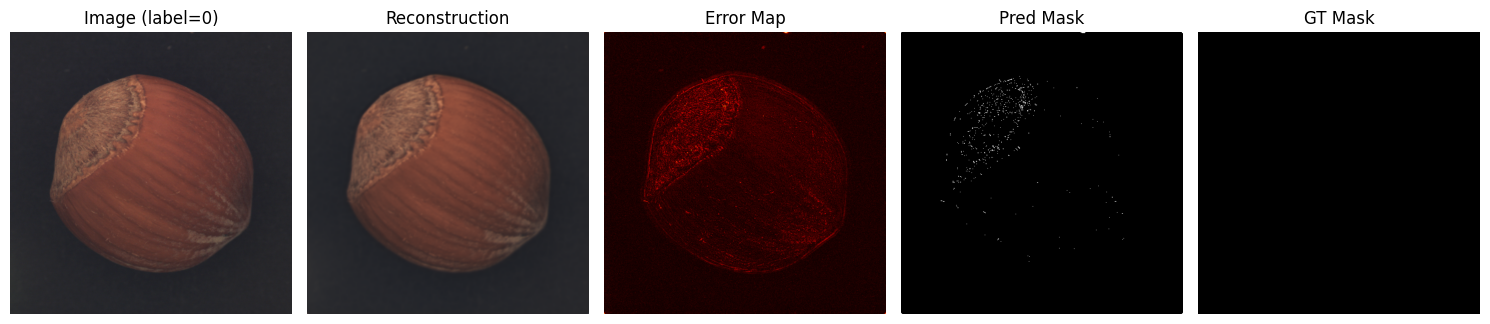

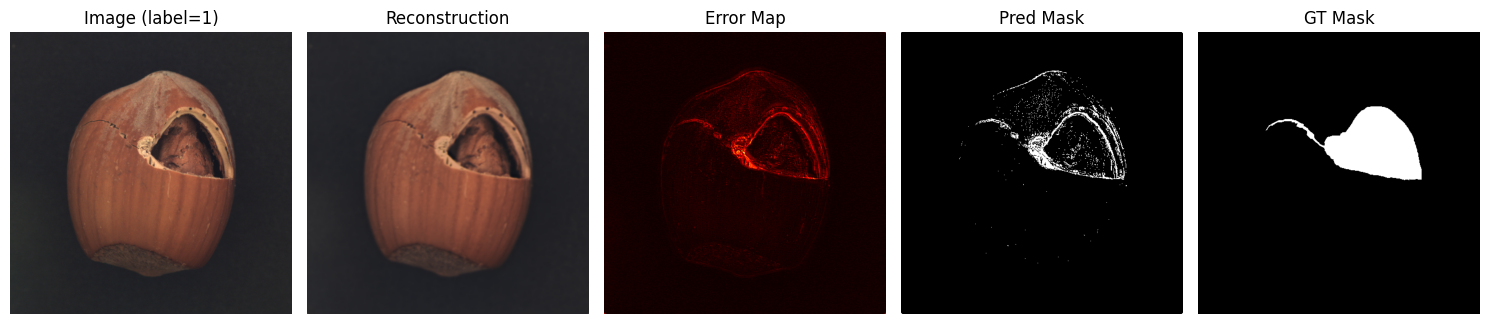

In [13]:
def show_one(index):
    img_path, mask_path, label = test_items[index]
    x = load_image(img_path)[None, ...]
    xhat = model.predict(x, verbose=0)
    e = recon_error_map(x, xhat).numpy()[0, :, :, 0]
    pred = (e > THRESH).astype(np.uint8)

    gt = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    if mask_path is not None:
        gt = load_mask(mask_path).numpy()[:, :, 0].astype(np.uint8)

    img_np = (x.numpy()[0] * 255).astype(np.uint8)
    recon_np = (xhat[0] * 255).astype(np.uint8)

    plt.figure(figsize=(15, 6))
    plt.subplot(1, 5, 1); plt.imshow(img_np); plt.axis("off"); plt.title(f"Image (label={label})")
    plt.subplot(1, 5, 2); plt.imshow(recon_np); plt.axis("off"); plt.title("Reconstruction")
    plt.subplot(1, 5, 3); plt.imshow(e, cmap="hot"); plt.axis("off"); plt.title("Error Map")
    plt.subplot(1, 5, 4); plt.imshow(pred, cmap="gray"); plt.axis("off"); plt.title("Pred Mask")
    plt.subplot(1, 5, 5); plt.imshow(gt, cmap="gray"); plt.axis("off"); plt.title("GT Mask")
    plt.tight_layout()
    plt.show()

good_idx = next(i for i,x in enumerate(test_items) if x[2] == 0)
bad_idx  = next(i for i,x in enumerate(test_items) if x[2] == 1)

show_one(good_idx)
show_one(bad_idx)